In [1]:
%run import_libs.py

In [2]:
root = 'Z:/yueying/gazeObject_YueyingDong/results/'

# Load scanmatch 

In [3]:
loadRaw = False
mergeTags = False
loadScanpath = True
trlType = ['precue','retrocue']
comparison = 'stim2delay'


In [4]:
"""load trial ordering"""
precuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/311to352/*.csv")
retrocuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/360to400/*.csv")

#load trial info
if len(trlType) != 0:
    thisPath = precuePath1 + retrocuePath1
elif trlType == 'precue':
    thisPath = precuePath1
else:
    thisPath = retrocuePath1

#load trl ordering    
trlOrdering = pd.DataFrame()
for i in thisPath:
    trlOrdering = pd.concat([trlOrdering,pd.read_csv(i).iloc[:,2:]]) 

trlOrdering = trlOrdering.reset_index(drop=True)

In [5]:
def loadScanPathRawMat_oneSubj(subjID,comparison = 'stim2delay'):
    # comparison = 'stim2delay', comparison = 'stim2delay_1sdelay' or comparison = 'stim2delay_2sdelay'
    
    experiment = '360to400'
    if subjID <= 352:
        experiment = '311to352'

    mat_data = loadmat(glob.glob(f'{root}/scanMatch_similarity/{experiment}_{comparison}/*{str(int(subjID))[:3]}*.mat')[0])
    similarityArr = mat_data['similarityArr']

    # zscore for each subj
    similarityArr = np.where(similarityArr == 9999,np.nan,similarityArr)
    similarityArr = (similarityArr - np.nanmean(similarityArr, ))/np.nanstd(similarityArr)
    return similarityArr

In [6]:
def loadRSA(loadScanpath,comparison,trlOrdering,normalizationMethod = 'zscore',debug = False):

    """load scan path similarity"""
    if loadScanpath == True:

        trl_withScore_formatted_sp = pd.DataFrame()

        """loop through the scanpath similarity matrix for all subject, extracting relevant information"""
        for subjID in trlOrdering.participant.unique():

            #initialize empty arrays
            withinTrl = []
            acrossTrl_sameImage = []
            acrossTrl_sameImage_vis = []
            acrossTrl_sameImage_ver = []
            acrossTrl_diffImage = []
            acrossTrl_diffImage_vis = []
            acrossTrl_diffImage_ver = []

            if (subjID <= 352) : #precue
                thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/311to352/*{str(int(subjID))[:3]}*.npy')
            else: #retrocue
                thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/360to400/*{str(int(subjID))[:3]}*.npy')

            #get the subj ID info, this will be used to check if the trl index are correct
            saccTrlIDs = np.load(thisFileID[0],allow_pickle = True)
            saccTrlIDs = [str((i.split('_')[0][1:],
                            int(i.split('_')[1]),
                            int(i.split('_')[2]))) for i in saccTrlIDs]

            print('handling...',subjID)

            # load the subject's scanmatch matrix
            similarityArr = loadScanPathRawMat_oneSubj(subjID)
            # get the trial info for this subject
            trlInfo_thisSubj = trlOrdering[trlOrdering.participant == subjID].reset_index(drop = True)
            
            #check if the trial is is correct
            if np.array_equal(trlInfo_thisSubj.TRIALID.values, saccTrlIDs):

                visual_mask = (trlInfo_thisSubj.trlType == 'visual')
                verbal_mask = (trlInfo_thisSubj.trlType == 'verbal')

                #for each trial
                for n,i in enumerate(trlInfo_thisSubj.TRIALID.unique()):  
                    #get the indices of other trials with the same image
                    trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i] 
                    image_this_trial = trlThis.stimImage.values[0]

                    
                    trial_mask = (trlInfo_thisSubj.TRIALID != i)
                    image_mask = (trlInfo_thisSubj.stimImage == image_this_trial)

                    
                    #compare current trial, to trials with the same image (the comparison trial is seperated into visual and verbal)
                    sameImageIndices = trlInfo_thisSubj[image_mask & trial_mask].index.values
                    sameImageIndices_vis = trlInfo_thisSubj[image_mask & trial_mask  & visual_mask].index.values
                    sameImageIndices_ver = trlInfo_thisSubj[image_mask & trial_mask  & verbal_mask].index.values

                    
                    #get the indices from other trls
                    diffImageIndices = trlInfo_thisSubj[~image_mask].index.values  
                    diffImageIndices_vis =  trlInfo_thisSubj[~image_mask & visual_mask].index.values
                    diffImageIndices_ver =  trlInfo_thisSubj[~image_mask & verbal_mask].index.values


                    #extract the similarity values using the index
                    withinTrl.append(similarityArr[n,n])
                    acrossTrl_sameImage.append(np.nanmean(similarityArr[n,sameImageIndices]))
                    acrossTrl_sameImage_vis.append(np.nanmean(similarityArr[n,sameImageIndices_vis]))
                    acrossTrl_sameImage_ver.append(np.nanmean(similarityArr[n,sameImageIndices_ver]))

                    acrossTrl_diffImage.append(np.nanmean(similarityArr[n,diffImageIndices]))
                    acrossTrl_diffImage_vis.append(np.nanmean(similarityArr[n,diffImageIndices_vis]))
                    acrossTrl_diffImage_ver.append(np.nanmean(similarityArr[n,diffImageIndices_ver]))


                    
            else:
                raise('the subject trial id from trlInfo_thisSubj does not match saccTrlId')
            
            similarityScores = pd.DataFrame(dict(zip(['within','across trial','diff image',
                                                    'across trial, visTarget','across trial, verTarget',
                                                    'diff image, visTarget','diff image, verTarget',],
                                                    [withinTrl,acrossTrl_sameImage,acrossTrl_diffImage,
                                                    acrossTrl_sameImage_vis, acrossTrl_sameImage_ver,
                                                    acrossTrl_diffImage_vis, acrossTrl_diffImage_ver])))
            if debug:
                print(f'/tab trl_withScore_formatted_sp shape is {trl_withScore_formatted_sp.shape}',
                    f'similarityScores shape is {similarityScores.shape}',
                    f'unique columns are {similarityScores.columns}')
            
            #append the subject to the larger df
            trl_withScore_formatted_sp = pd.concat([trl_withScore_formatted_sp,similarityScores],axis = 0)

        #necessary formatting
        trl_withScore = pd.concat([trlOrdering,trl_withScore_formatted_sp.reset_index(drop = True)],axis = 1)
        trl_withScore['trlOrder'] = [ast.literal_eval(i)[2] * 20 + ast.literal_eval(i)[1] for i in trl_withScore.TRIALID]
        trl_withScore['imageRepeate'] = trl_withScore.sort_values('trlOrder',ascending=True).groupby(['participant','stimImage',]).cumcount()
        trl_withScore['imageRepeate_trlType'] = trl_withScore.sort_values('trlOrder',ascending=True).groupby(['participant','stimImage','trlType']).cumcount()
        
        #make it from wide to long
        trl_withScore_formatted_sp = pd.melt(trl_withScore,  
                                             id_vars=['trlType','participant','TRIALID','stimImage','imageRepeate','imageRepeate_trlType'],
                                                        value_vars=['within', 'across trial', 'diff image',
                                                                    'across trial, visTarget','across trial, verTarget',
                                                                    'diff image, visTarget','diff image, verTarget'],
                                                        var_name='category', value_name=f'similarityScore_{comparison}')
        
        return trl_withScore_formatted_sp
   

In [7]:
#create a plotting function that plots the difference score, for both cue tasks
#that shows visvis - visver and verver - vervis for each trial (base on whether the current trial is vis or ver)
#then take average, generate plot and calculate statistics
def plotConditionalDiff_Score(ax,comparison = 'stim2delay',score = 'similarityScore',meanType = 'subj'):
    
    #transform the trl_withScore_formatted
    loadWhat = f'{score}_{comparison}' 
    acrossTrlTemp = trl_withScore_formatted[trl_withScore_formatted.category !='within']
    acrossTrlDiff = acrossTrlTemp.pivot(index = 'TRIALID',columns = 'category', values=loadWhat).reset_index()

    #calculate the diff score
    #the diffScore_byTargetTrl is for every trial, vis - ver
    #the diffScore_byTargetTrl_signCorrected is, for every trial, use the congruent score (vis-vis, ver-ver) minus the other one
    acrossTrlDiff = acrossTrlDiff.merge(acrossTrlTemp[['TRIALID','participant','trlType','task','imageRepeate','stimImage']].drop_duplicates(),how = 'left')
    acrossTrlDiff['diffScore_byTargetTrl'] = acrossTrlDiff['across, same image, visTarget'] - acrossTrlDiff['across, same image, verTarget']
    acrossTrlDiff['diffScore_byTargetTrl_signCorrected'] = [visScore - verScore if acrossTrlDiff.trlType[n] == 'visual' else verScore - visScore for n,(verScore,visScore) in enumerate(zip(acrossTrlDiff['across, same image, verTarget'],
                                                                                acrossTrlDiff['across, same image, visTarget']))]
    
    #take mean
    if meanType == 'subj':
        print('calculating subject mean')
        acrossTrlDiffMean = acrossTrlDiff.groupby(['task','participant','trlType',]).mean(numeric_only=True).reset_index()
    else:
        acrossTrlDiffMean = acrossTrlDiff
    

    #fig,ax = plt.subplots(ncols = len(categoryOrder4Plotting), figsize = (20,10),sharex=True,sharey=True)

    
    f = sns.barplot(x = 'task',hue = 'trlType', order = ['precue','retrocue'],hue_order = ['visual','verbal'],
                palette=['green','purple',], y = 'diffScore_byTargetTrl_signCorrected',data = acrossTrlDiffMean,alpha = 0.5,ax = ax)


    
    
    ax.set_xlabel('condition',fontsize = 15)
    ax.set_title(f'mean {score} score \n congruent comparison - incongruent, {comparison}',y = 1,fontsize = 10)
   
    return acrossTrlDiffMean


In [8]:
if loadRaw:

    trl_withScore_formatted = loadRSA(loadScanpath = True,comparison='stim2delay',trlOrdering=trlOrdering)

    if mergeTags:
        #load in psychopy file
        psyFull = pd.DataFrame()
        for i in glob.glob(f'{root}data/psychopy/*csv'):
            psyFull = pd.concat([psyFull,pd.read_csv(i)],axis = 0)
        psyFull = psyFull.reset_index(drop=True).drop_duplicates()


        #select the relevant cols, add some necessary tags
        trlInfo = psyFull[['trlType', 'corrAns','TRIALID','rspThisTrl', 'rtThisTrl']]
        trlInfo['participant'] = [ast.literal_eval(i)[0] for i in psyFull.TRIALID]
        trlInfo['corrAns_text'] = np.where(psyFull.corrAns == 0,'same','diff')
        trlInfo['rspErr'] = trlInfo.rspThisTrl == trlInfo.corrAns_text
        trlInfo['rspMade'] = (trlInfo.rspThisTrl.isnull() == False)

        #zscore rt
        rtZ = pd.DataFrame()

        for i in trlInfo.participant.unique():
            #take z value in regard to subj
            flattenedSubj = trlInfo[(trlInfo.participant == i)].rtThisTrl.values
            thisSubj_z = stats.zscore(flattenedSubj,nan_policy = 'omit')
            
            #replace the value with zscored value
            rtZ = pd.concat([rtZ,pd.DataFrame(thisSubj_z)],axis = 0)

        trlInfo['rtZ'] = rtZ.values

        #agg the other metrics
        ipaDf = pd.read_csv(f"{root}ipa/ipaDf.csv").iloc[:,1:]
        vviq = pd.read_csv(f"{root}data/vviq/vviq_311to400.csv")

        #ipa
        aggMetricDf = trl_withScore_formatted.merge(ipaDf)
        #vviq
        aggMetricDf = aggMetricDf.merge(vviq,left_on='participant',right_on='subj',how = 'left').drop('subj',axis = 1)
        #behavioral metrics
        aggMetricDf = aggMetricDf.merge(trlInfo.drop('participant',axis = 1))

        aggMetricDf['task'] = ['precue' if int(i) < 352 else 'retrocue' 
                                        for i in aggMetricDf.participant]

    if os.path.exists(f'{root}similarityMetricsAgg/trl2trl_withBehav.csv'):
        print('file exists')
    else:
        aggMetricDf.to_csv(f'{root}similarityMetricsAgg/trl2trl_withBehav.csv')
else:
        trl_withScore_formatted = pd.read_csv(f'{root}similarityMetricsAgg/trl2trl_withBehav_withDiffImageByCondition.csv').iloc[:,1:]

        col_rename = {
            'within':'within',
            'across, same image': 'across trial',
            'across, same image, visTarget': 'across trial, visTarget',
            'across, same image, verTarget': 'across trial, verTarget',
            'across, diff image':'diff image',
            'across, diff image, verTarget':'diff image, verTarget',
            'across, diff image, visTarget':'diff image, visTarget',
        }
        a = [col_rename.get(old_label) for old_label in trl_withScore_formatted.category.values]
        trl_withScore_formatted['category'] = a


# Figure 2D

In [9]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [10]:
comparison = 'stim2delay'
what2Draw =  ['within', 'across trial', 'diff image']

In [11]:
meanDf = trl_withScore_formatted.groupby(['participant','category','task',]).mean(numeric_only=True).reset_index()
meanDf = meanDf[meanDf.category.isin(what2Draw)]

In [12]:
anova_results = pg.mixed_anova(data=meanDf, dv=f'similarityScore_{comparison}',
               within='category', between='task', subject='participant',
               effsize='np2')
anova_results

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,task,0.013,1,80,0.013,7.501,0.008,0.086,NaN
1,category,0.354,2,160,0.177,113.115,0.000,0.586,0.575
2,Interaction,0.007,2,160,0.004,2.342,0.099,0.028,NaN


In [13]:
def report_stats(category):
    precue = meanDf[(meanDf.task == 'precue') & (meanDf.category == category)][f'similarityScore_{comparison}'].values
    retrocue = meanDf[(meanDf.task == 'retrocue') & (meanDf.category == category)][f'similarityScore_{comparison}'].values
    result = stats.ttest_ind(precue, retrocue, nan_policy='omit')
    print(category.capitalize() + ':', 
          f"t ({result.df}) = {result.statistic:.3f}, p = {result.pvalue:.3f}, ",
          'cohen d:', round(cohenD(precue, retrocue), 2))

for  category in ['within', 'across trial', 'diff image']:
    report_stats(category)


Within: t (80.0) = 1.528, p = 0.130,  cohen d: 0.34
Across trial: t (80.0) = 5.548, p = 0.000,  cohen d: 1.23
Diff image: t (80.0) = -1.015, p = 0.313,  cohen d: -0.22


In [14]:
# pairwise test
contrasts = [
    ('within', 'across trial', 'within -> across trial'),
    ('across trial', 'diff image', 'across trial -> diff image'),
]

for task in ['precue', 'retrocue']:
    print(f'\n--- {task} ---')
    sub = meanDf[meanDf.task == task].sort_values('participant')
    for cat_a, cat_b, label in contrasts:
        a = sub[sub.category == cat_a][f'similarityScore_{comparison}']
        b = sub[sub.category == cat_b][f'similarityScore_{comparison}']
        t, p = stats.ttest_rel(a, b, nan_policy='omit')
        d = round(cohenD(a, b), 2)
        print(f'  {label:35s}  t ({len(a) + len(b) - 2}) = {t:.3f}, p={p:.3f}, d={d}')


--- precue ---
  within -> across trial               t (80) = 5.491, p=0.000, d=1.17
  across trial -> diff image           t (80) = 9.815, p=0.000, d=2.22

--- retrocue ---
  within -> across trial               t (80) = 8.956, p=0.000, d=1.93
  across trial -> diff image           t (80) = 2.921, p=0.006, d=0.59


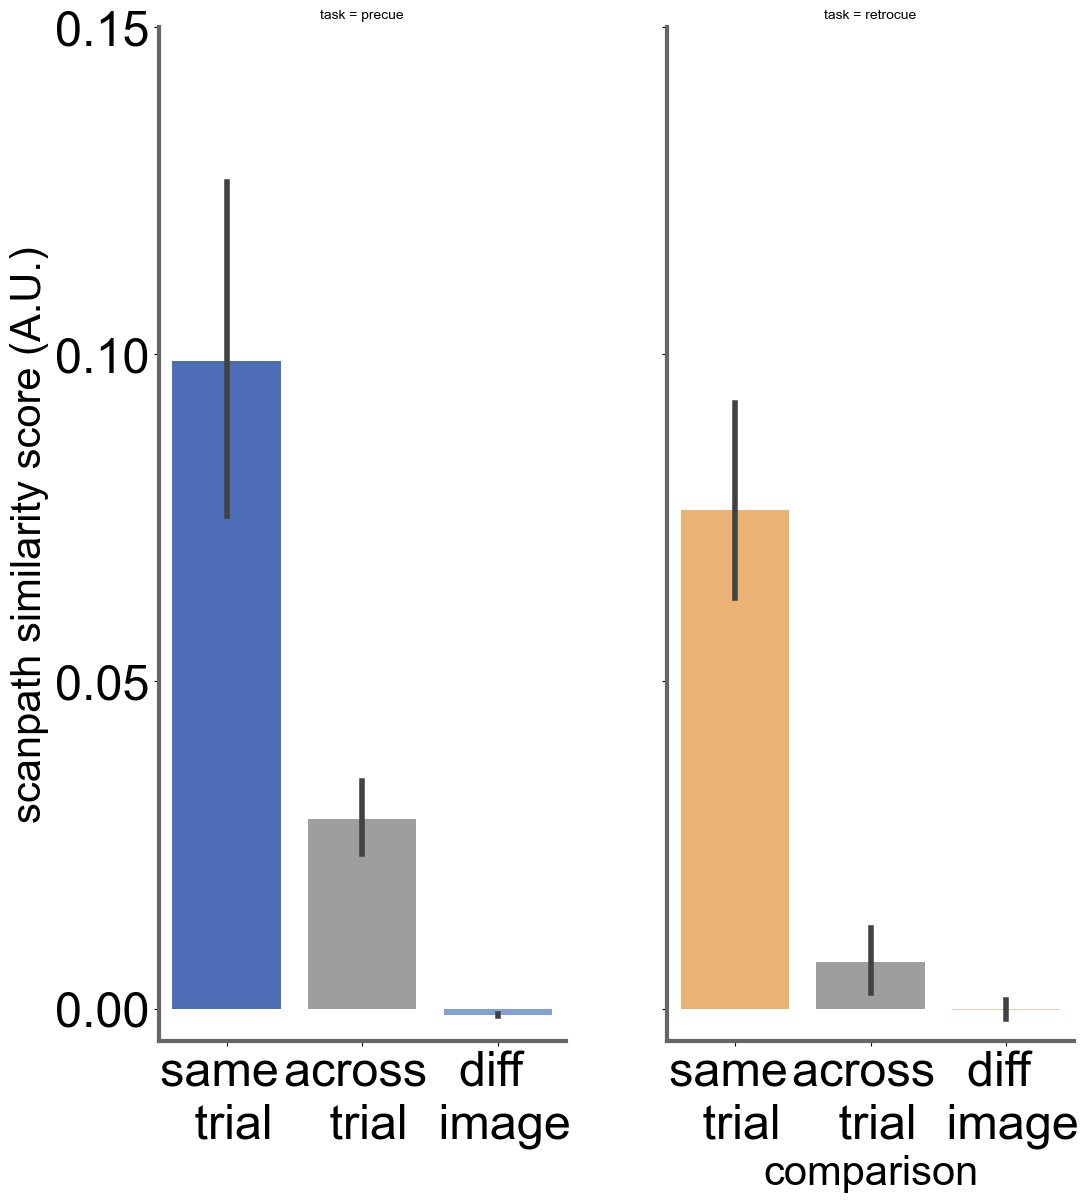

In [15]:
meanDf_noCondition = trl_withScore_formatted.groupby(['participant','category','task',]).mean(numeric_only=True).reset_index()
acrossSameDiff_noCondition = meanDf_noCondition[meanDf_noCondition.category.isin(what2Draw)]


if comparison !='stim2delay':
    melted = pd.melt(acrossSameDiff_noCondition, id_vars=['participant','category','task'], value_vars=['similarityScore_stim2stim','similarityScore_delay2delay'], 
                  var_name='comparison', value_name='similarityScore')
    f = sns.catplot(hue = 'category', x = 'task', y =f'similarityScore',
                hue_order = what2Draw,palette=['#9e9e9eff','#759ce0',],
                aspect=0.5,height=10,kind = 'bar', linewidth = 5,
            data = melted[melted.comparison =='similarityScore_stim2stim'])
    #plt.xticks(ticks=[0, 1], labels=[ 'stim\nto\nstim', 'delay\nto\ndelay'],fontsize = 30)
    
    ax = f.axes[0, 0]
    colors = ['#82a0d3','#e2ccae','#9e9e9eff','#9e9e9eff',]
    for bar, color in zip(ax.patches, colors):
        
        bar.set_facecolor(color)
    f.fig.set_size_inches(10, 12)

    #ax.lines[0].set_color('#79c7b8')
    #ax.lines[1].set_color('#79c7b8')
    #ax.lines[2].set_color('#79c7b8')
    f.fig.set_size_inches(10, 12)

else:
    
    f = sns.catplot(x = 'category', hue = 'category', palette = ['#9e9e9eff','#759ce0','#3b66c8',],y =f'similarityScore_{comparison}',
                order = what2Draw,
                col = 'task',aspect=0.5,height=10,kind = 'bar',errwidth = 4,
            data = acrossSameDiff_noCondition)
    plt.xticks(ticks=[0, 1, 2], labels=['same \n trial', 'across \n trial', 'diff \n image'])
    ax = f.axes[0, 1]
    colors = ['#9e9e9eff','#e2ccae','#eab375',]
    for bar, color in zip(ax.patches, colors):
        bar.set_facecolor(color)
    f.fig.set_size_inches(10, 12)



plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.05))
f.set_axis_labels('comparison','scanpath similarity score (A.U.)',fontsize = 30)




for ax in f.axes.flat:
    ax.tick_params(labelsize=35)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')


f.axes[0, 0].set_xlabel('',fontsize = 15)

plt.subplots_adjust(top=0.9)

plt.ylim(-0.005,0.15)

plt.subplots_adjust(wspace=0.25)



# Figure 3B

In [16]:
meanDf_conditioned = trl_withScore_formatted.groupby(['participant','category','task','trlType']).mean(numeric_only=True).reset_index()

acrossSameDiff = meanDf_conditioned[meanDf_conditioned.category.isin([
                    'within',
                    'across trial, visTarget',
                    'across trial, verTarget',
                    'diff image, visTarget',
                    'diff image, verTarget',
                    ])].reset_index(drop = True)

In [17]:
# add in tags

tarType = []
for targetType,baseType in zip(acrossSameDiff.category,acrossSameDiff.trlType):
    if 'vis' in targetType:
        tarType.append('visual')
    elif 'ver' in targetType:
        tarType.append('verbal')
    else:
        tarType.append(baseType)

acrossSameDiff['targetType'] = tarType

cateType = []
for i in acrossSameDiff.category:
    if 'across' in i:
        cateType.append('across trial')
    elif 'diff' in i:
        cateType.append('diff image')
    else:
        cateType.append('within')
acrossSameDiff['category'] = cateType

In [18]:
aov = pg.rm_anova(data = acrossSameDiff[(acrossSameDiff.trlType == acrossSameDiff.targetType) &
                                        (acrossSameDiff.task == 'precue')], dv = f'similarityScore_{comparison}',
    within = ['category','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)

aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,category,0.431,2,80,0.215,44.994,0.000,0.000,0.529,0.561
1,trlType,0.301,1,40,0.301,19.551,0.000,0.000,0.328,1.000
2,category * trlType,0.002,2,80,0.001,1.315,0.274,0.273,0.032,0.861


In [19]:
# posthoc
sub = acrossSameDiff[
    (acrossSameDiff.task == 'precue') &
    (acrossSameDiff.trlType == acrossSameDiff.targetType)
].sort_values('participant')

for cat, label in [('within', 'within'), ('across trial', 'across trial'), ('diff image', 'diff image')]:
    vis = sub[(sub.category == cat) & (sub.trlType == 'visual')].similarityScore_stim2delay
    ver = sub[(sub.category == cat) & (sub.trlType == 'verbal')].similarityScore_stim2delay
    t, p = ttest_rel(vis, ver, nan_policy='omit')
    d = round(cohenD(vis, ver), 2)
    print(f'  {cat:15s}  t({len(vis) + len(ver) -2}) ={t:.3f}, p={p:.4f}, d={d}')


  within           t(80) =4.131, p=0.0002, d=0.7
  across trial     t(80) =4.415, p=0.0001, d=1.27
  diff image       t(80) =4.192, p=0.0001, d=1.31


In [20]:
aov = pg.rm_anova(data = acrossSameDiff[(acrossSameDiff.trlType == acrossSameDiff.targetType) &
                                        (acrossSameDiff.task == 'retrocue')], dv = f'similarityScore_{comparison}',
    within = ['category','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,category,0.287,2,80,0.144,83.796,0.000,0.000,0.677,0.646
1,trlType,0.036,1,40,0.036,1.628,0.209,0.209,0.039,1.000
2,category * trlType,0.000,2,80,0.000,0.015,0.985,0.970,0.000,0.807


In [21]:
sub = acrossSameDiff[
    (acrossSameDiff.task == 'retrocue') &
    (acrossSameDiff.trlType == acrossSameDiff.targetType)
].sort_values('participant')

for cat, label in [('within', 'within'), ('across trial', 'across trial'), ('diff image', 'diff image')]:
    vis = sub[(sub.category == cat) & (sub.trlType == 'visual')].similarityScore_stim2delay
    ver = sub[(sub.category == cat) & (sub.trlType == 'verbal')].similarityScore_stim2delay
    t, p = ttest_rel(vis, ver, nan_policy='omit')
    d = round(cohenD(vis, ver), 2)
    print(f'  {cat:15s}  t({len(vis) + len(ver) -2}) ={t:.3f}, p={p:.4f}, d={d}')


  within           t(80) =1.145, p=0.2590, d=0.3
  across trial     t(80) =1.269, p=0.2117, d=0.37
  diff image       t(80) =1.336, p=0.1892, d=0.42


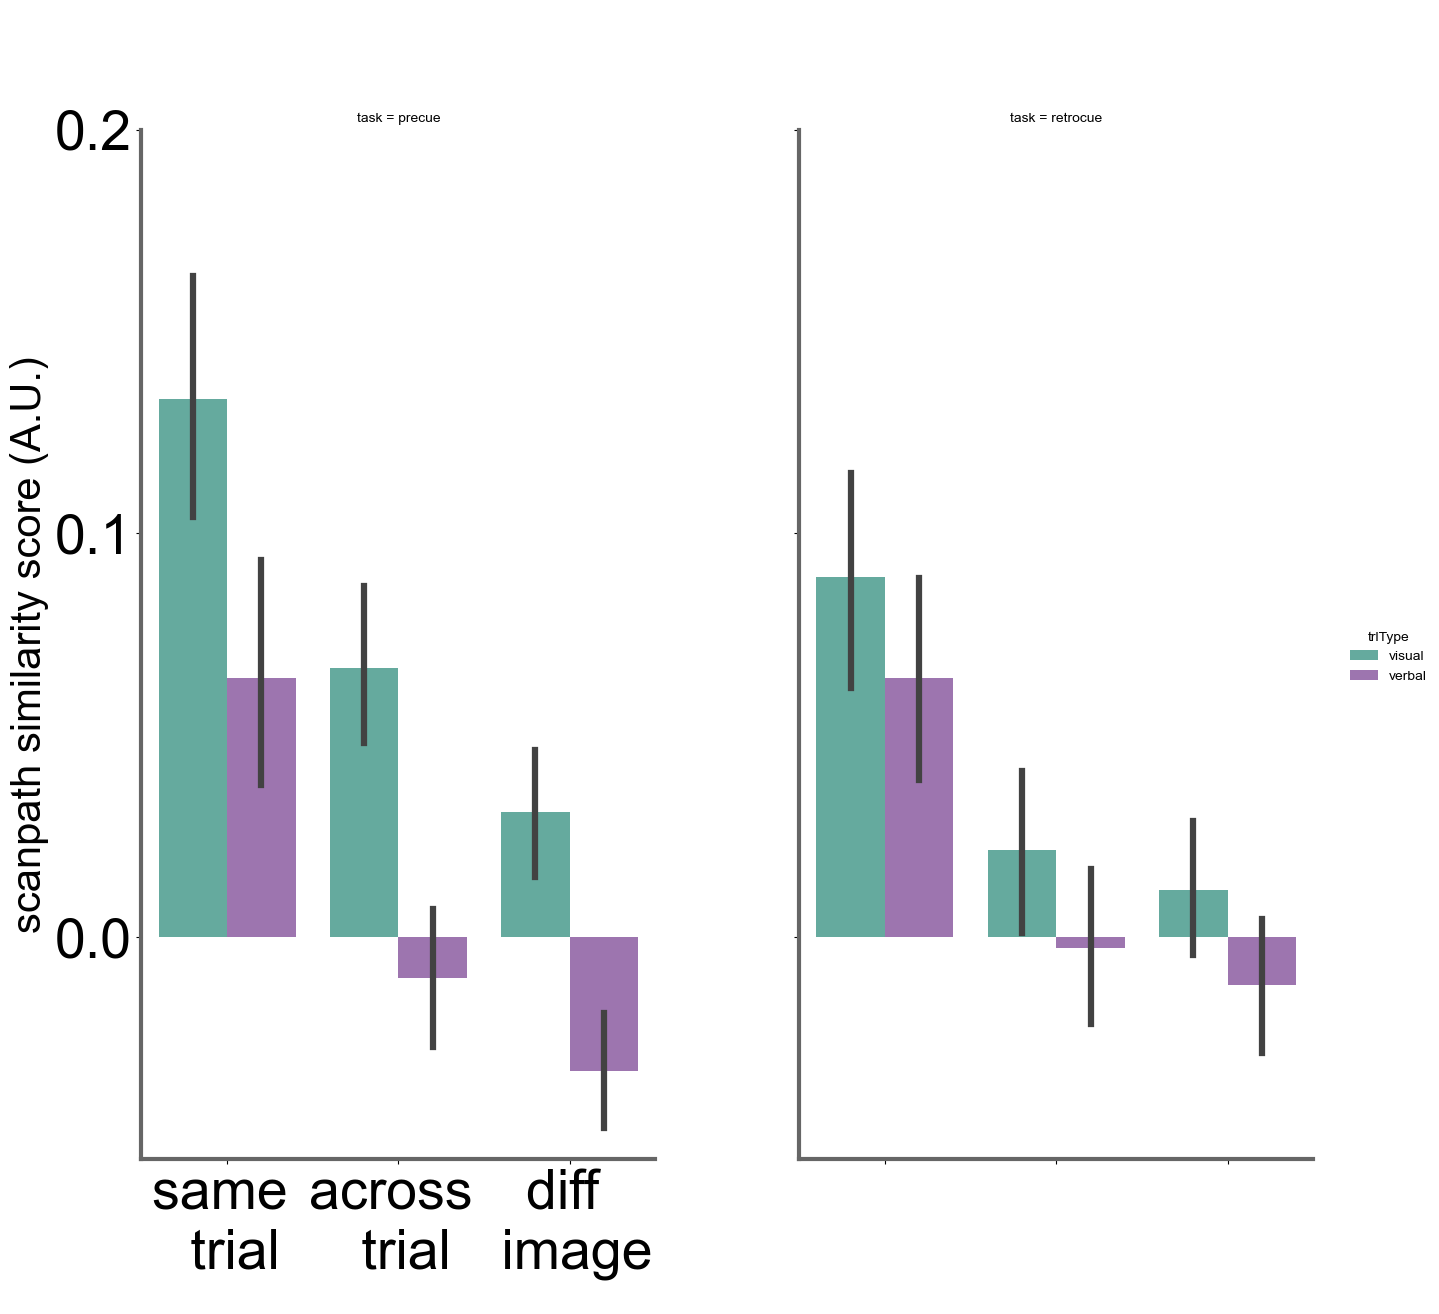

In [22]:
f = sns.catplot(x = 'category', y =f'similarityScore_{comparison}',hue = 'trlType',
                order = ['within','across trial','diff image'],
                col = 'task',aspect=0.4,height=13,linewidth = 5,errwidth = 4.5,
            palette = ['#59b6a6','#a06bb9'],hue_order=['visual','verbal'],kind = 'bar',
            data = acrossSameDiff[acrossSameDiff.trlType == acrossSameDiff.targetType])

for ax in f.axes.flat:
    ax.tick_params(labelsize=30)

f.fig.set_size_inches(14, 12)
plt.xticks(ticks=[0, 1, 2],color = 'white', labels=['same \n trial', 'across \n trial', 'diff \n image'])

f.set_axis_labels('comparison','scanpath similarity score (A.U.)',fontsize = 30)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

f.axes[0, 0].set_xlabel('',fontsize = 15)
f.axes[0, 1].set_xlabel('',fontsize = 15)

if comparison == 'stim2stim':
    f.axes.flat[0].text(x = -0.01,y = 0.25, s = 'ns',fontdict={'fontsize':20})
elif comparison =='delay2delay':
    f.axes.flat[0].text(x = -0.01,y = 0.055, s = 'sig interaction',fontdict={'fontsize':20})
    f.axes.flat[1].text(x = -0.01,y = 0.055, s = 'almost sig interaction',fontdict={'fontsize':20})

plt.xlabel('condition',fontsize = 15,color = 'white')
plt.subplots_adjust(top=0.9)
plt.suptitle(f'subj average \n {comparison} comparison',color = 'white',fontsize = 20,y = 1)

#plt.ylim(2.4,2.55)
plt.ylim(-0.055,0.2)
plt.subplots_adjust(wspace=0.28)

for ax in f.axes.flat:
    ax.tick_params(labelsize=40)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')

# Figure 3E

In [23]:
congruency_df = acrossSameDiff[acrossSameDiff.category != 'within']
congruency_df['baseTar'] = congruency_df.trlType + '-' + congruency_df.targetType
congruency_df['congruency'] = np.where(congruency_df.baseTar.isin(['visual-visual','verbal-verbal']),'congruent','incongruent')

In [24]:
aov = pg.rm_anova(data = congruency_df[( congruency_df.task == 'precue') &\
                                       (congruency_df.category == 'across trial')], 
                  dv = f'similarityScore_{comparison}',
    within = ['congruency','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,congruency,0.000,1,40,0.000,0.056,0.815,0.815,0.001,1.000
1,trlType,0.052,1,40,0.052,6.642,0.014,0.014,0.142,1.000
2,congruency * trlType,0.070,1,40,0.070,6.731,0.013,0.013,0.144,1.000


In [25]:
aov = pg.rm_anova(data = congruency_df[( congruency_df.task == 'retrocue') &\
                                       (congruency_df.category == 'across trial')], 
                  dv = f'similarityScore_{comparison}',
    within = ['congruency','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,congruency,0.001,1,40,0.001,2.395,0.130,0.130,0.056,1.000
1,trlType,0.000,1,40,0.000,0.020,0.889,0.889,0.000,1.000
2,congruency * trlType,0.021,1,40,0.021,2.289,0.138,0.138,0.054,1.000


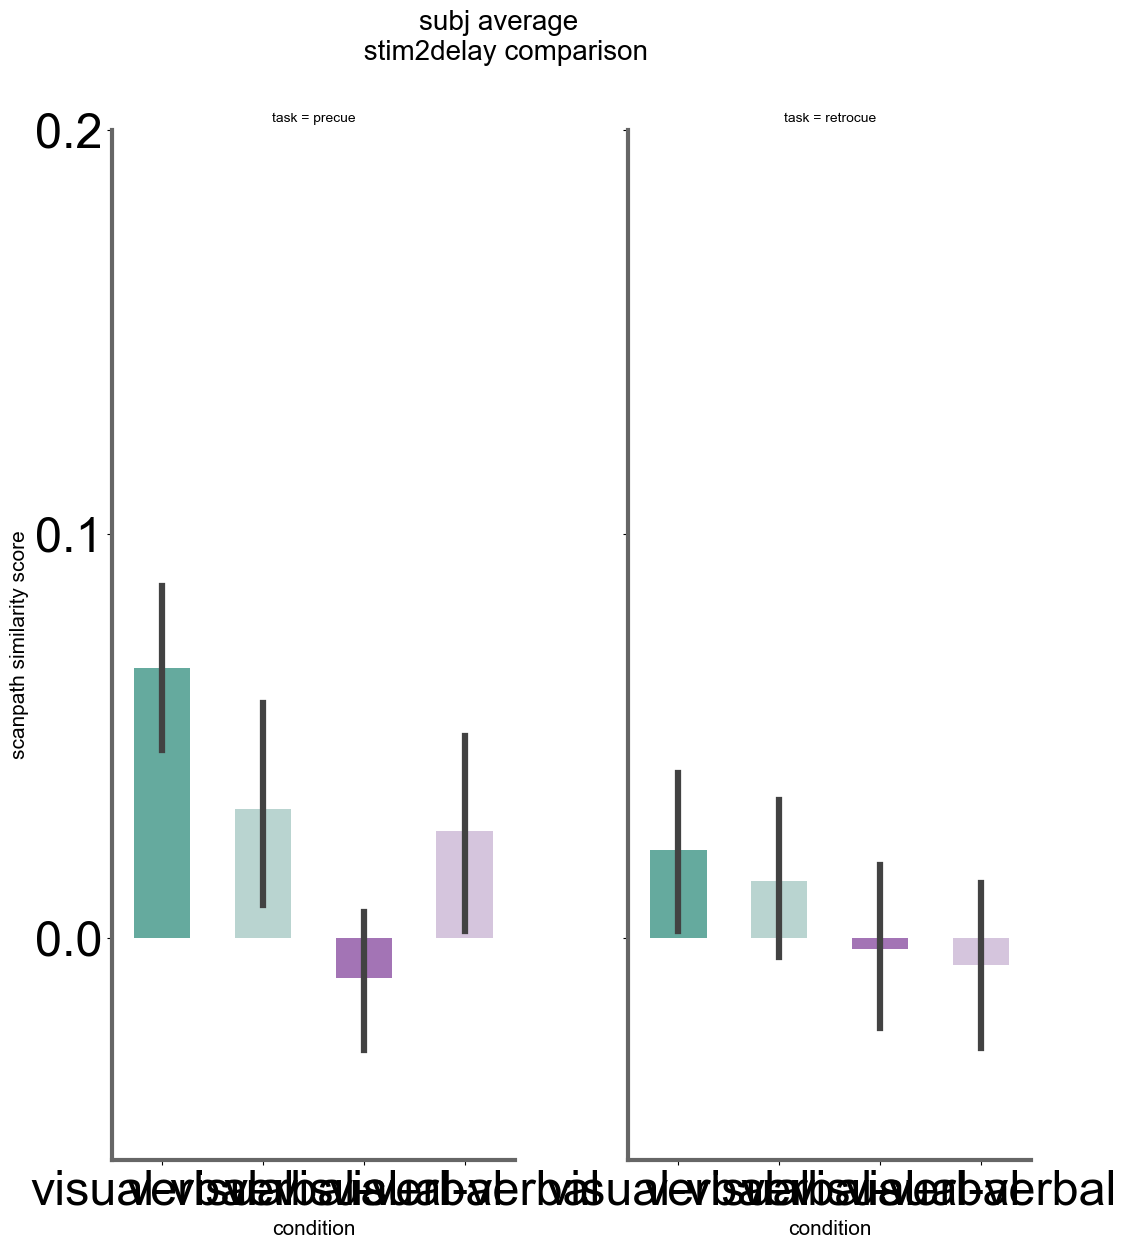

In [26]:
colors = ['#59b6a6','#b4d9d3','#a869c0','#d7c1e1'] #['#82c495','#82c495','#a869c0','#a869c0']

f = sns.catplot(hue = 'baseTar', y =f'similarityScore_{comparison}',x = 'baseTar',
                hue_order = ['visual-visual','verbal-visual','verbal-verbal','visual-verbal',],
                col = 'task',aspect=0.15,height=13,linewidth = 5,errwidth = 4.5,
            palette = colors, order = ['visual-visual','verbal-visual','verbal-verbal','visual-verbal',],kind = 'bar',
            data = congruency_df[congruency_df.category == 'across trial'])
f.set_axis_labels('condition','scanpath similarity score',fontsize = 15)

f.fig.set_size_inches(13, 12)
for ax in f.axes.flat:
    ax.tick_params(labelsize=30)
    for patch in ax.patches:
        current_width = patch.get_width()
        new_width = current_width * 0.7  # Adjust this factor to control spacing
        patch.set_width(new_width)

        # Center the bar if desired (adjusting x-position)
        x = patch.get_x()
        patch.set_x(x + (current_width - new_width) / 2)


ax = f.axes[0, 1]

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))


if comparison =='delay2delay':
    f.axes.flat[1].text(0,0.07,'sig interaction',fontdict={'fontsize':20})

plt.xlabel('condition',fontsize = 15)
plt.subplots_adjust(top=0.9)
plt.suptitle(f'subj average \n {comparison} comparison',fontsize = 20,y = 1)
plt.ylim(-0.055,0.2)
plt.subplots_adjust(wspace=0.28)

for ax in f.axes.flat:
    ax.tick_params(labelsize=35)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')


# Supplementary Figure 2

In [27]:
comparison = 'stim2delay'

In [28]:
aov = pg.rm_anova(data = congruency_df[( congruency_df.task == 'precue') &\
                                       (congruency_df.category == 'diff image')], 
                  dv = f'similarityScore_{comparison}',
    within = ['congruency','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,congruency,0.000,1,40,0.000,0.040,0.842,0.842,0.001,1.000
1,trlType,0.048,1,40,0.048,6.049,0.018,0.018,0.131,1.000
2,congruency * trlType,0.036,1,40,0.036,4.727,0.036,0.036,0.106,1.000


In [29]:
aov = pg.rm_anova(data = congruency_df[( congruency_df.task == 'retrocue') &\
                                       (congruency_df.category == 'diff image')], 
                  dv = f'similarityScore_{comparison}',
    within = ['congruency','trlType'],subject = 'participant',
    effsize = 'np2')

aov['p-unc'] = aov['p-unc'].round(5)
aov

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,congruency,0.000,1,40,0.000,1.372,0.248,0.248,0.033,1.000
1,trlType,0.000,1,40,0.000,0.008,0.929,0.929,0.000,1.000
2,congruency * trlType,0.020,1,40,0.020,2.902,0.096,0.096,0.068,1.000


(-0.05, 0.2)

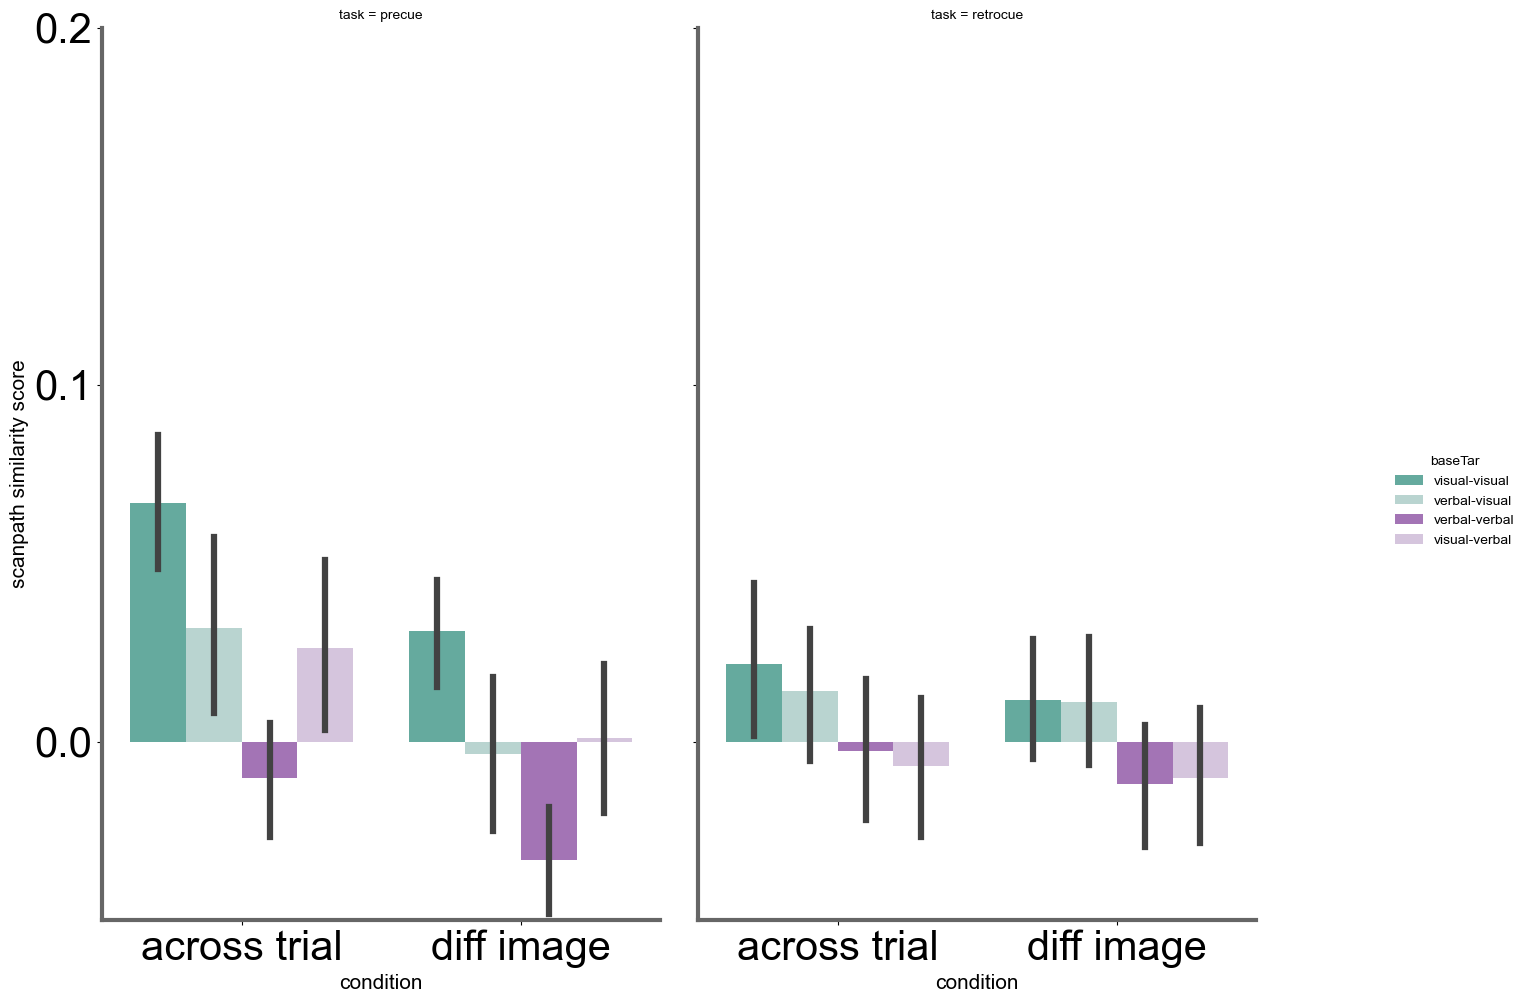

In [40]:
colors = ['#59b6a6','#b4d9d3','#a869c0','#d7c1e1'] 

f = sns.catplot(hue = 'baseTar', y =f'similarityScore_{comparison}',x = 'category',
                hue_order = ['visual-visual','verbal-visual','verbal-verbal','visual-verbal'],
                palette = colors,
               aspect=1,height=3.5,linewidth = 5,errwidth = 4.5,
               order= ['across trial','diff image'],
                kind = 'bar',col = 'task',
            data = congruency_df)
f.set_axis_labels('condition','scanpath similarity score',fontsize = 15)

f.fig.set_size_inches(16, 12)
for ax in f.axes.flat:
    ax.tick_params(labelsize=30)
    style_spines(ax, which_spines=['left','bottom'])
ax = f.axes[0, 0]

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.xlabel('condition',fontsize = 15)
plt.subplots_adjust(top=0.9)
plt.ylim(-0.05,0.2)